**Housing Sale price prediction -**

    What are the important things to consider when one thinks of buying a house?

    1. Locality ( a safe, secure and friendly neighborhood)
    2. Square Foot
    3. Number of bedrooms
    4. Number of Bathrooms
    5. Kitchen
    6. Garage and Basement
    7. Year of built 
    8. New or resale house
    9. Additional Utilities
    10. Ofcourse a resonable Price for the house with all required features.
    
    Well, the above features will definitely give an idea of the Price of the house theoritically . But 
    will our ML algorithm be able to predict accurately, if so, how accurately?

    This will be our approach at predicting the price of an unknown house - 

    1. Load pacakages and data
    2. Analyse Sale Price 
    3. Multivariate Analysis
    4. Cleaning and Imputing Missing Data
    5. Feature Engineering
    6. Modeling and Prediction

**1. Load packages and data**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import accuracy_score,r2_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold,KFold

import xgboost as xgb
import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')

In [2]:
train = pd.read_csv('../input/train.csv')
test = pd.read_csv('../input/test.csv')

#test_labels = test.loc[:,'Id'].values

#train.drop("Id", axis = 1, inplace = True)
#test.drop("Id", axis = 1, inplace = True)

In [3]:
train.shape,test.shape

((1460, 81), (1459, 80))

**2. Analyse Sale Price**

In [4]:
train['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

    Lowest Sale Price     : $ 34900
    Highest Sale Price    : $ 755000
    Average Sale Price    : $ 180921 

    This can be visualized using the seaborn distribution plot
    
    It will be interesting to understand what factors contribute to the price of a house

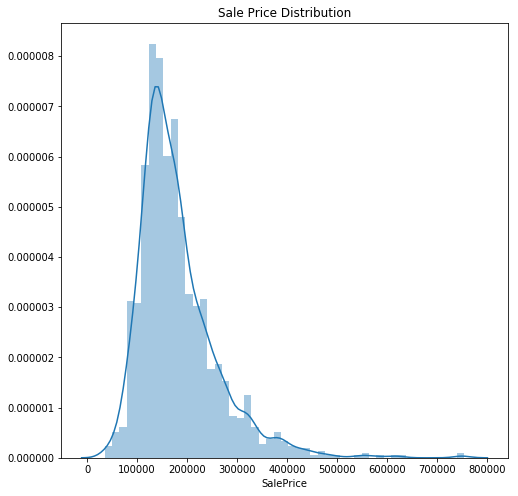

In [5]:
plt.figure(figsize=(8,8))
sns.distplot(train['SalePrice'],norm_hist=True)

plt.title('Sale Price Distribution')
plt.show()

  **3. Multivariate Analysis**
  
      The dataset has 2 types of features - numeric and categorical

In [6]:
categorical = train.select_dtypes('O').columns
print("Categorical Data:",len(categorical))
print(categorical)

numeric = train.select_dtypes(['int','float']).columns
print("\nNumeric Data:",len(numeric))
print(numeric)

Categorical Data: 43
Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

Numeric Data: 38
Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBat

    80 is a lot of feature to analyse. So let's just concentrate on 5 most correlated features with the 
    Sale Price which is our target

In [7]:
print("5 most correlated features")
n = 6
corr_matrix = train.corr()
corr_matrix.nlargest(n,'SalePrice')['SalePrice']

5 most correlated features


SalePrice      1.000000
OverallQual    0.790982
GrLivArea      0.708624
GarageCars     0.640409
GarageArea     0.623431
TotalBsmtSF    0.613581
Name: SalePrice, dtype: float64

    We will ignore Saleprice and plot the correlation with rest with SalePrice
        
    OverallQual : Rates the overall material and finish of the house (1= Very Poor,10 = Very Excellent)
    GrLivArea   : Above grade (ground) living area square feet
    GarageCars  : Size of garage in car capacity
    GarageArea  : Size of garage in square feet
    TotalBsmtSF : Total square feet of basement area

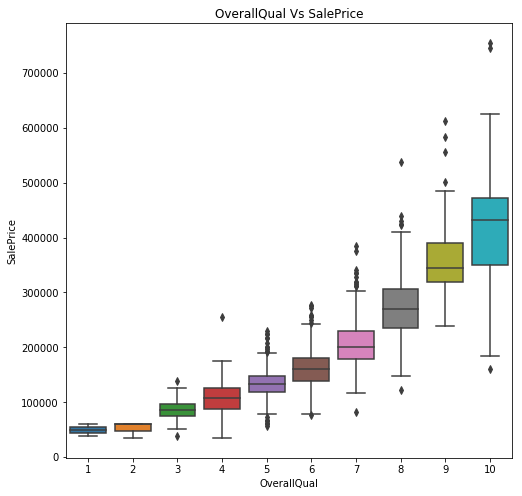

In [8]:
plt.figure(figsize=(8,8))
plt.title("OverallQual Vs SalePrice")
sns.boxplot(x=train['OverallQual'],y=train['SalePrice']);

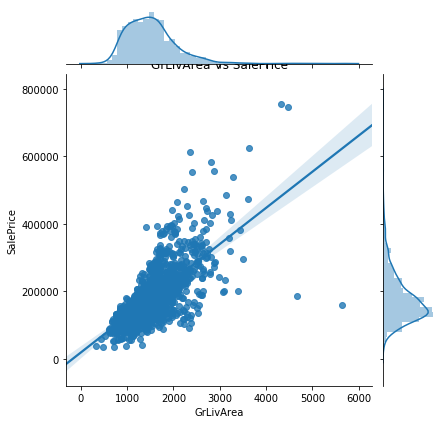

In [9]:
sns.jointplot(x=train['GrLivArea'],y=train['SalePrice'],kind='reg')
plt.title("GrLivArea Vs SalePrice");

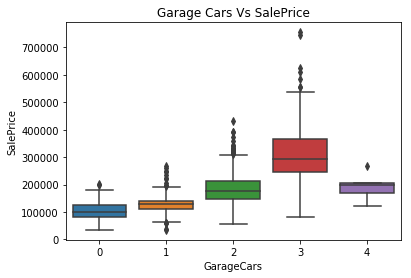

In [10]:
sns.boxplot(x=train['GarageCars'],y=train['SalePrice'])
plt.title("Garage Cars Vs SalePrice");

*More number of Garage-Cars, should have more Saleprice. But in the boxplot above, 4-car garage has very less sale price. Let's get rid of this outlier and plot again.*

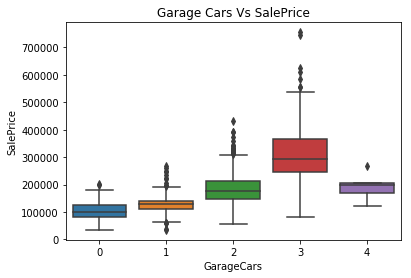

In [11]:
rows = train [(train['GarageCars'] > 3) & (train['SalePrice'] < 300000)]
rows = train [(train['GarageCars'] > 3) & (train['SalePrice'] < 300000)].index

sns.boxplot(x=train['GarageCars'],y=train['SalePrice'])
plt.title("Garage Cars Vs SalePrice");

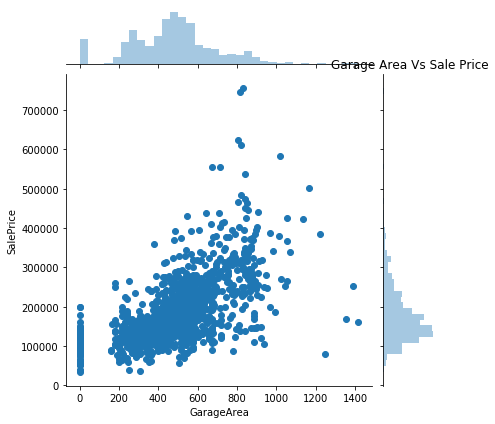

In [12]:
sns.jointplot(train['GarageArea'],train['SalePrice']);
plt.title("Garage Area Vs Sale Price");

    Looks like this too has some outliers. More Garage area has less Saleprice

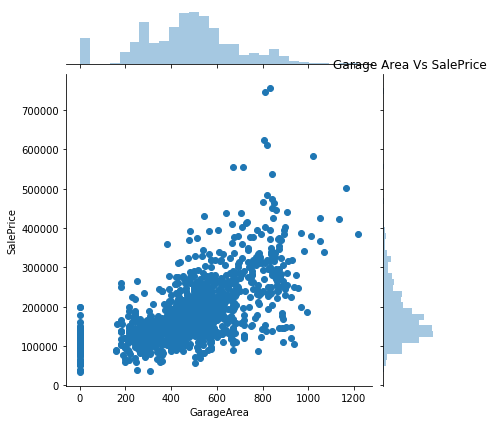

In [13]:
rows = train[(train['GarageArea'] > 1000) & (train['SalePrice'] < 300000)].index

train = train.drop(rows)

sns.jointplot(x=train['GarageArea'],y=train['SalePrice'])
plt.title("Garage Area Vs SalePrice");

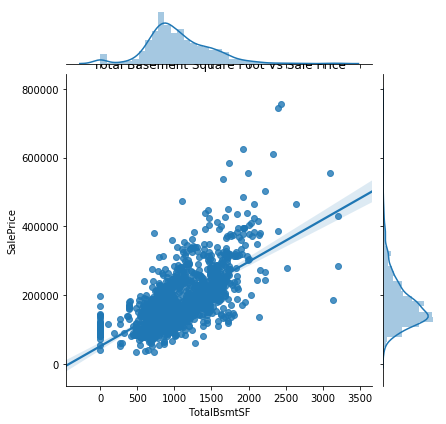

In [14]:
sns.jointplot(train['TotalBsmtSF'],train['SalePrice'],kind='reg')
plt.title("Total Basement Square Foot Vs Sale Price");

**4. Imputing Missing Values**

In [15]:
#Concatenate the training and testing data for easy clean up
housing_df = pd.concat([train, test], keys=['train', 'test'])

In [16]:
#PoolQC : NA means "No Pool"        
housing_df['PoolQC'] = housing_df['PoolQC'].fillna('NoPOOL')

#MiscFeature : NA means "no misc feature"
housing_df['MiscFeature'] = housing_df['MiscFeature'].fillna("NOMISC")

#Alley : NA means "no alley access"
housing_df['Alley'] = housing_df['Alley'].fillna('NOACCESS')

#Fence : NA means "no fence"
housing_df['Fence'] = housing_df['Fence'].fillna('NOFENCE')

#FireplaceQu : NA means "no fireplace"
housing_df['FireplaceQu'] = housing_df['Fence'].fillna('NOFP')

#LotFrontage : fill it with median
housing_df['LotFrontage'] = housing_df['LotFrontage'].fillna(housing_df['LotFrontage'].median())

#GarageType, GarageFinish, GarageQual and GarageCond : Replacing missing data with "None".
for col in ('GarageType', 'GarageFinish', 'GarageQual', 'GarageCond'):
    housing_df[col] = housing_df[col].fillna('None')

#GarageYrBlt, GarageArea and GarageCars : Replacing missing data with 0.
for col in ('GarageYrBlt', 'GarageArea', 'GarageCars'):
    housing_df[col] = housing_df[col].fillna(0)

#BsmtFinSF1, BsmtFinSF2, BsmtUnfSF, TotalBsmtSF, BsmtFullBath and BsmtHalfBath: Replace with 0
for col in ('BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath','BsmtHalfBath'):
    housing_df[col] = housing_df[col].fillna(0)
            
#BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1 and BsmtFinType2 : replace  NaN with 'NOBASE'.
for col in ('BsmtQual', 'BsmtCond', 'BsmtExposure','BsmtFinType1','BsmtFinType2'):
    housing_df[col] = housing_df[col].fillna('NOBASE')

#MasVnrArea and MasVnrType :  fill 0 for the area and None for the type.
housing_df['MasVnrArea'] = housing_df['MasVnrArea'].fillna(0)
housing_df['MasVnrType'] = housing_df['MasVnrType'].fillna('None')

#MSZoning (The general zoning classification) : Fill with mode
housing_df['MSZoning'] = housing_df['MSZoning'].fillna(housing_df['MSZoning'].mode)

#Utilities : drop 
housing_df = housing_df.drop(['Utilities'],axis=1)

#Functional : data description says NA means typical.
housing_df['Functional'] = housing_df['Functional'].fillna('Typical')

#Electrical : one NA value,set it to mode
housing_df['Electrical'] = housing_df['Electrical'].fillna(housing_df['Electrical'].mode()[0])

#KitchenQual: one NA value,set it to mode
housing_df['KitchenQual'] = housing_df['KitchenQual'].fillna(housing_df['KitchenQual'].mode()[0])

#Exterior1st and Exterior2nd : one NA value each,set it to mode
housing_df['Exterior1st'] = housing_df['Exterior1st'].fillna(housing_df['Exterior1st'].mode()[0])
housing_df['Exterior2nd'] = housing_df['Exterior2nd'].fillna(housing_df['Exterior2nd'].mode()[0])

#SaleType : one NA value each,set it to mode
housing_df['SaleType'] = housing_df['SaleType'].fillna(housing_df['SaleType'].mode()[0])

#MSSubClass : replace missing values with None
housing_df['MSSubClass'] = housing_df['MSSubClass'].fillna('None')

#Total Square Foot
housing_df['TotalSF'] = housing_df['TotalBsmtSF'] + housing_df['1stFlrSF'] + housing_df['2ndFlrSF']

housing_df.drop(['TotalBsmtSF', '1stFlrSF', '2ndFlrSF'], axis=1, inplace=True)

In [17]:
housing_df['MSSubClass']   = housing_df['MSSubClass'].astype(str)
housing_df['OverallCond']  = housing_df['OverallCond'].astype(str)
housing_df['KitchenAbvGr'] = housing_df['KitchenAbvGr'].astype(str)
housing_df['YrSold']       = housing_df['YrSold'].astype(str)
housing_df['MoSold']       = housing_df['MoSold'].astype(str)
housing_df['MSZoning']     = housing_df['MSZoning'].astype(str)

In [18]:
#housing_df.drop(['Fireplaces', 'FireplaceQu','Fireplaces', 'FireplaceQu','YrSold', 'MoSold','Condition1', 'Condition2','Exterior1st', 'Exterior2nd','RoofMatl', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'Heating', 'LowQualFinSF',
#               'BsmtFullBath', 'BsmtHalfBath', 'Functional', 'GarageYrBlt', 'GarageArea', 'GarageCond', 'WoodDeckSF',
#               'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC', 'Fence', 'MiscFeature', 'MiscVal'],
#              axis=1, inplace=True)

    LabelEncoding of the features below 

In [19]:
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()

categorical = ( 'BsmtQual', 'BsmtCond', 'GarageQual', 'GarageCond', 
        'ExterQual', 'ExterCond','HeatingQC', 'PoolQC', 'KitchenQual', 'BsmtFinType1', 
        'BsmtFinType2', 'Functional', 'Fence', 'BsmtExposure', 'GarageFinish', 'LandSlope',
        'LotShape', 'PavedDrive', 'Street', 'Alley', 'CentralAir', 'MSSubClass', 'OverallCond', 
        'YrSold', 'MoSold','BldgType','Condition1' ,'Condition2'  ,'Electrical', 'Exterior1st', 'Exterior2nd' ,'Foundation', 'GarageType', 'Heating' 
        ,'HouseStyle', 'KitchenAbvGr', 'LandContour', 'LotConfig','MiscFeature', 'Neighborhood' ,'RoofMatl' ,'RoofStyle', 'SaleCondition',
         'SaleType','MasVnrType','MSZoning')

for col in categorical:
    label.fit(housing_df[col].values)
    housing_df[col] = label.transform(housing_df[col].values)
    
housing_df.head()

3SsnPorch  Alley  BedroomAbvGr  BldgType  BsmtCond  BsmtExposure  \
train 0          0      1             3         0         4             4   
      1          0      1             3         0         4             1   
      2          0      1             3         0         4             2   
      3          0      1             3         0         1             4   
      4          0      1             4         0         4             0   

         BsmtFinSF1  BsmtFinSF2  BsmtFinType1  BsmtFinType2  ...  SalePrice  \
train 0       706.0         0.0             2             6  ...   208500.0   
      1       978.0         0.0             0             6  ...   181500.0   
      2       486.0         0.0             2             6  ...   223500.0   
      3       216.0         0.0             0             6  ...   140000.0   
      4       655.0         0.0             2             6  ...   250000.0   

         SaleType  ScreenPorch  Street  TotRmsAbvGrd  WoodDeckSF  YearBuilt  \
train 0         8            0       1             8           0       2003   
      1         8            0       1             6         298       1976   
      2         8            0       1             6           0       2001   
      3         8            0       1             7           0       1915   
      4         8            0       1             9         192       2000   

         YearRemodAdd  YrSold  TotalSF  
train 0          2003       2   2566.0  
      1          1976       1   2524.0  
      2          2002       2   2706.0  
      3          1970       0   2473.0  
      4          2000       2   3343.0  

[5 rows x 78 columns]

In [20]:
housing_df = pd.get_dummies(housing_df)
housing_df

3SsnPorch  Alley  BedroomAbvGr  BldgType  BsmtCond  BsmtExposure  \
train 0             0      1             3         0         4             4   
      1             0      1             3         0         4             1   
      2             0      1             3         0         4             2   
      3             0      1             3         0         1             4   
      4             0      1             4         0         4             0   
...               ...    ...           ...       ...       ...           ...   
test  1454          0      1             3         3         4             4   
      1455          0      1             3         4         4             4   
      1456          0      1             4         0         4             4   
      1457          0      1             3         0         4             0   
      1458          0      1             3         0         4             0   

            BsmtFinSF1  BsmtFinSF2  BsmtFinType1  BsmtFinType2  ...  \
train 0          706.0         0.0             2             6  ...   
      1          978.0         0.0             0             6  ...   
      2          486.0         0.0             2             6  ...   
      3          216.0         0.0             0             6  ...   
      4          655.0         0.0             2             6  ...   
...                ...         ...           ...           ...  ...   
test  1454         0.0         0.0             6             6  ...   
      1455       252.0         0.0             5             6  ...   
      1456      1224.0         0.0             0             6  ...   
      1457       337.0         0.0             2             6  ...   
      1458       758.0         0.0             3             6  ...   

            WoodDeckSF  YearBuilt  YearRemodAdd  YrSold  TotalSF  \
train 0              0       2003          2003       2   2566.0   
      1            298       1976          1976       1   2524.0   
      2              0       2001          2002       2   2706.0   
      3              0       1915          1970       0   2473.0   
      4            192       2000          2000       2   3343.0   
...                ...        ...           ...     ...      ...   
test  1454           0       1970          1970       0   1638.0   
      1455           0       1970          1970       0   1638.0   
      1456         474       1960          1996       0   2448.0   
      1457          80       1992          1992       0   1882.0   
      1458         190       1993          1994       0   2996.0   

            FireplaceQu_GdPrv  FireplaceQu_GdWo  FireplaceQu_MnPrv  \
train 0                     0                 0                  0   
      1                     0                 0                  0   
      2                     0                 0                  0   
      3                     0                 0                  0   
      4                     0                 0                  0   
...                       ...               ...                ...   
test  1454                  0                 0                  0   
      1455                  0                 0                  0   
      1456                  0                 0                  0   
      1457                  0                 0                  1   
      1458                  0                 0                  0   

            FireplaceQu_MnWw  FireplaceQu_NOFENCE  
train 0                    0                    1  
      1                    0                    1  
      2                    0                    1  
      3                    0                    1  
      4                    0                    1  
...                      ...                  ...  
test  1454                 0                    1  
      1455                 0                    1  
      1456                 0                    1  
      1457          

    Exclude the Id and SalePrice in scaling.

In [21]:
housing_df_standardized = housing_df[housing_df.columns[~housing_df.columns.isin(['Id','SalePrice'])]]

housing_df_standardized = (housing_df_standardized - housing_df_standardized.mean())/housing_df_standardized.std()

housing_df_standardized['Id'] = housing_df.loc[:,'Id']

housing_df_standardized['SalePrice'] = housing_df.loc[:,'SalePrice']


In [22]:
#Seperate the train labels - target and features
train_labels = housing_df_standardized.loc['train','SalePrice']
train_data = housing_df_standardized.loc['train'].drop(['Id','SalePrice'],axis=1).select_dtypes(include=[np.number])

#Extract the Id for test_label
test_label = housing_df_standardized.loc['test','Id']
test_data = housing_df_standardized.loc['test'].drop(['Id','SalePrice'],axis=1).select_dtypes(include=[np.number])
#

In [23]:
X = train_data.copy()
y = train_labels.copy()
X_submission = test_data.copy()

In [24]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3)

In [25]:
GBoost = GradientBoostingRegressor(n_estimators=3000, learning_rate=0.05, max_depth=3, max_features='sqrt',
                                               min_samples_leaf=15, min_samples_split=10, loss='huber')
gbr = GBoost.fit(X_train.values, y_train.values)

#cross_val_score(GBoost, X_test.values, y_test.values, cv=5)
#print("GBoost Accuracy: %0.2f (+/- %0.2f)" % (scores.mean(), scores.std() * 2))
#sale_pred = model_gboost.predict(X_submission)

print("Random Forest Regressor Score :",gbr.score(X_test,y_test))

Random Forest Regressor Score : 0.8898341063955956


In [26]:
#pd.DataFrame({'Id': test_label, 'SalePrice': sale_pred}).to_csv('my_submission_gsb.csv', index =False)    #

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import VotingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

In [28]:
lr= LinearRegression()
lr.fit(X_train,y_train)

print("Linear Regression Accuracy :",lr.score(X_test,y_test))

Linear Regression Accuracy : 0.8542231761989458


In [29]:
rfr= RandomForestRegressor(n_estimators=3000,max_depth=4, random_state=0)
rfr.fit(X_train,y_train)

print("Random Forest Regressor Score :",rfr.score(X_test,y_test))

Random Forest Regressor Score : 0.8117159335923353


In [30]:
dr= DecisionTreeRegressor(max_depth=4,random_state=0)
dr.fit(X_train,y_train)

print("Decision Tree Regressor Score :",dr.score(X_test,y_test))

Decision Tree Regressor Score : 0.6648264558890158


In [31]:
br = BaggingRegressor()
br.fit(X_train,y_train)
print("Bagging Regressor Score :",br.score(X_test,y_test))

Bagging Regressor Score : 0.8263948563240275


In [32]:
adar = AdaBoostRegressor(random_state=0,n_estimators=1000)
adar.fit(X_train,y_train)

print("AdaBoost Regressor Score :",adar.score(X_test,y_test))

AdaBoost Regressor Score : 0.833912546250406


In [33]:
voting_r = VotingRegressor(estimators=[('Linear Regression', lr),("Random Forest Regressor",rfr),("Decsion Tree Regressor",dr),("Bagging Regressor",br),("AdaBoost Regressor",adar),("Gradient Boost Regressor",gbr)],n_jobs=-1)

voting_r.fit(X_train,y_train)

print("Voting Regressor Score :",voting_r.score(X_test,y_test))

Voting Regressor Score : 0.8498395165179785


In [34]:
sale_pred = voting_r.predict(X_submission)
pd.DataFrame({'Id': test_label, 'SalePrice': sale_pred}).to_csv('my_submission_voting.csv', index =False)    #